In [1]:
import numpy as np
import math
from numba import njit
import time
seed = np.random.seed(69)

def parse_files(r_text, in_text):
    # Determine all unique species
    species_set = set()
    reactions_raw = []
    for line in r_text.strip().split('\n'):
        if not line.strip(): continue
        parts = line.split(':')
        if len(parts) < 3: continue
        react = {parts[0].strip().split()[i]: int(parts[0].strip().split()[i+1]) for i in range(0, len(parts[0].strip().split()), 2)}
        prod = {parts[1].strip().split()[i]: int(parts[1].strip().split()[i+1]) for i in range(0, len(parts[1].strip().split()), 2)}
        rate = float(parts[2].strip())
        species_set.update(react.keys())
        species_set.update(prod.keys())
        reactions_raw.append((react, prod, rate))

    species_list = list(species_set)
    species_to_idx = {s: i for i, s in enumerate(species_list)}
    
    # Pre-allocate numeric arrays for Numba
    num_reactions = len(reactions_raw)
    num_species = len(species_list)
    
    reactants_stoich = np.zeros((num_reactions, num_species), dtype=np.int32)
    state_update = np.zeros((num_reactions, num_species), dtype=np.int32)
    rates = np.zeros(num_reactions, dtype=np.float64)
    
    for i, (r, p, rate) in enumerate(reactions_raw):
        rates[i] = rate
        for sp, count in r.items():
            reactants_stoich[i, species_to_idx[sp]] = count
            state_update[i, species_to_idx[sp]] -= count
        for sp, count in p.items():
            state_update[i, species_to_idx[sp]] += count
            
    initial_state_array = np.zeros(num_species, dtype=np.int32)
    for line in in_text.strip().split('\n'):
        if not line.strip(): continue
        parts = line.split()
        if 'GE' not in parts and parts[0] in species_to_idx:
            initial_state_array[species_to_idx[parts[0]]] = int(parts[1])
            
    return reactants_stoich, state_update, rates, initial_state_array, species_to_idx

# Numba decorator compiles this Python function to C-level machine code
@njit
def fast_gillespie(reactants_stoich, state_update, rates, initial_state, 
                   moi_idx, ci2_idx, cro2_idx, target_moi, trials):
    
    stealth_count = 0
    num_reactions, num_species = reactants_stoich.shape
    
    for _ in range(trials):
        state = initial_state.copy()
        state[moi_idx] = target_moi
        
        while True:
            # Check thresholds
            if state[ci2_idx] >= 145:
                stealth_count += 1
                break
            if state[cro2_idx] >= 55:
                break
                
            # Compute Propensities
            propensities = np.zeros(num_reactions)
            a0 = 0.0
            
            for i in range(num_reactions):
                a_j = rates[i]
                valid = True
                for j in range(num_species):
                    req = reactants_stoich[i, j]
                    if req > 0:
                        count = state[j]
                        if count < req:
                            a_j = 0.0
                            valid = False
                            break
                        # Combinatorial combinations
                        if req == 1:
                            a_j *= count
                        elif req == 2:
                            a_j *= count * (count - 1) * 0.5
                        elif req == 3:
                            a_j *= count * (count - 1) * (count - 2) / 6.0
                if valid:
                    propensities[i] = a_j
                    a0 += a_j
                    
            if a0 == 0.0: break # Deadlock
            
            # Select Reaction
            r = np.random.random() * a0
            cumulative = 0.0
            reaction_idx = -1
            for i in range(num_reactions):
                cumulative += propensities[i]
                if r <= cumulative:
                    reaction_idx = i
                    break
            
            # Update state vector instantly
            if reaction_idx != -1:
                for j in range(num_species):
                    state[j] += state_update[reaction_idx, j]
                    
    return stealth_count / trials

def main():
    try:
        with open('lambda.r', 'r') as f: r_file_content = f.read()
        with open('lambda.in.txt', 'r') as f: in_file_content = f.read()
    except Exception as e:
        print(f"Error loading files: {e}"); return
        
    reactants, updates, rates, init_state, sp_idx = parse_files(r_file_content, in_file_content)
    
    moi_idx = sp_idx['MOI']
    ci2_idx = sp_idx['cI2']
    cro2_idx = sp_idx['Cro2']
    
    print("Pre-compiling Numba function (this takes ~3 seconds)...")
    # Numba compiles on the first execution
    _ = fast_gillespie(reactants, updates, rates, init_state, moi_idx, ci2_idx, cro2_idx, 1, 1)

    print("\nMOI | P(Stealth) | P(Hijack) | Time")
    print("----|------------|-----------|-------")
    
    mois = list(range(1, 11))
    probabilities = []
    
    for moi in mois:
        start_time = time.time()
        # With numba, we can blast through 200 trials effortlessly
        p_stealth = fast_gillespie(reactants, updates, rates, init_state, moi_idx, ci2_idx, cro2_idx, moi, 300)
        probabilities.append(p_stealth)
        elapsed = time.time() - start_time
        print(f"{moi:3} | {p_stealth:.3f}      | {1-p_stealth:.3f}     | {elapsed:.2f}s")

if __name__ == '__main__':
    main()

Pre-compiling Numba function (this takes ~3 seconds)...

MOI | P(Stealth) | P(Hijack) | Time
----|------------|-----------|-------
  1 | 0.237      | 0.763     | 153.55s
  2 | 0.207      | 0.793     | 67.64s
  3 | 0.210      | 0.790     | 46.77s
  4 | 0.243      | 0.757     | 37.82s
  5 | 0.283      | 0.717     | 32.41s
  6 | 0.327      | 0.673     | 28.86s
  7 | 0.303      | 0.697     | 24.55s
  8 | 0.260      | 0.740     | 15.13s
  9 | 0.313      | 0.687     | 15.21s
 10 | 0.333      | 0.667     | 14.89s


MOI | P(Stealth) | P(Hijack) | Time
----|------------|-----------|-------
  1 | 0.237      | 0.763     | 153.55s
  2 | 0.207      | 0.793     | 67.64s
  3 | 0.210      | 0.790     | 46.77s
  4 | 0.243      | 0.757     | 37.82s
  5 | 0.283      | 0.717     | 32.41s
  6 | 0.327      | 0.673     | 28.86s
  7 | 0.303      | 0.697     | 24.55s
  8 | 0.260      | 0.740     | 15.13s
  9 | 0.313      | 0.687     | 15.21s
 10 | 0.333      | 0.667     | 14.89s

Graph successfully saved to 'lambda_decision_300.png'


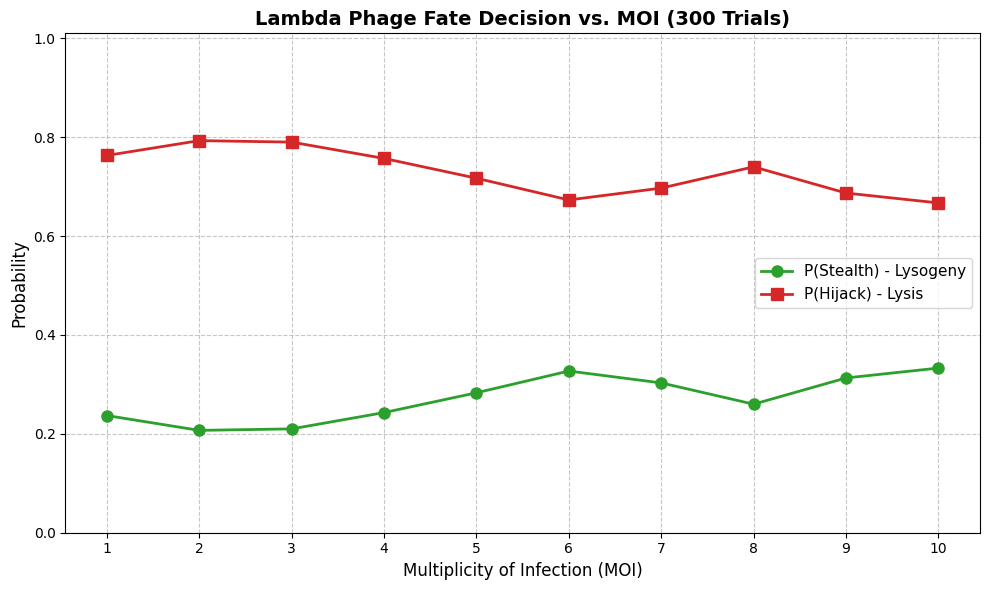

In [3]:
import matplotlib.pyplot as plt

def plot_lambda_results():
    # Your exact 300-trial data
    moi = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    p_stealth = [0.237, 0.207, 0.210, 0.243, 0.283, 0.327, 0.303, 0.260, 0.313, 0.333]
    p_hijack = [0.763, 0.793, 0.790, 0.757, 0.717, 0.673, 0.697, 0.740, 0.687, 0.667]

    plt.figure(figsize=(10, 6))
    
    # Plotting both probabilities
    plt.plot(moi, p_stealth, marker='o', linestyle='-', color='#2ca02c', label='P(Stealth) - Lysogeny', linewidth=2, markersize=8)
    plt.plot(moi, p_hijack, marker='s', linestyle='-', color='#d62728', label='P(Hijack) - Lysis', linewidth=2, markersize=8)

    # Formatting the graph
    plt.title('Lambda Phage Fate Decision vs. MOI (300 Trials)', fontsize=14, fontweight='bold')
    plt.xlabel('Multiplicity of Infection (MOI)', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.xticks(moi)
    plt.ylim(0, 1.01)
    plt.legend(fontsize=11, loc='center right')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('lambda_decision_300.png', dpi=300)
    print("Graph successfully saved to 'lambda_decision_300.png'")

if __name__ == '__main__':
    plot_lambda_results()